# Clase 6: Representation Learning y Reducción de Dimensionalidad

## Inteligencia Artificial - Ingeniería Mecatrónica

**Docente:** Diego Stalder (dstalder@ing.una.py)

**Fecha:** 26 de Agosto de 2026

---

## Contenido del Notebook

1. **Toy Models y Visualización**
   - Datos sintéticos 2D y 3D
   - Visualización interactiva

2. **PCA (Principal Component Analysis)**
   - Ejemplo con datos 2D
   - Ejemplo con datos 3D
   - Aplicación a MNIST
   - Varianza explicada

3. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**
   - Comparación con PCA
   - Efecto de la perplejidad
   - Visualización de clusters

4. **UMAP (Uniform Manifold Approximation and Projection)**
   - Comparación con PCA y t-SNE
   - Efecto de parámetros

5. **Word Embeddings**
   - Word2Vec con texto simple
   - Visualización de embeddings
   - Analogías semánticas

6. **Aplicación: Rendimiento Académico**
   - Reducción de dimensionalidad
   - Visualización de clusters de estudiantes
   - Análisis de patrones

In [4]:
# =============================================================================
# IMPORTS
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Scikit-learn
from sklearn.datasets import make_blobs, make_moons, make_circles, load_digits, fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# UMAP (instalar con: pip install umap-learn)
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP no instalado. Instalar con: pip install umap-learn")

# Gensim para Word2Vec (instalar con: pip install gensim)
try:
    from gensim.models import Word2Vec
    GENSIM_AVAILABLE = True
except ImportError:
    GENSIM_AVAILABLE = False
    print("Gensim no instalado. Instalar con: pip install gensim")

# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Bibliotecas cargadas correctamente")

✅ Bibliotecas cargadas correctamente


---
## 1. Toy Models: Datos Sintéticos

### 1.1 Datos en 2D - Formas Simples

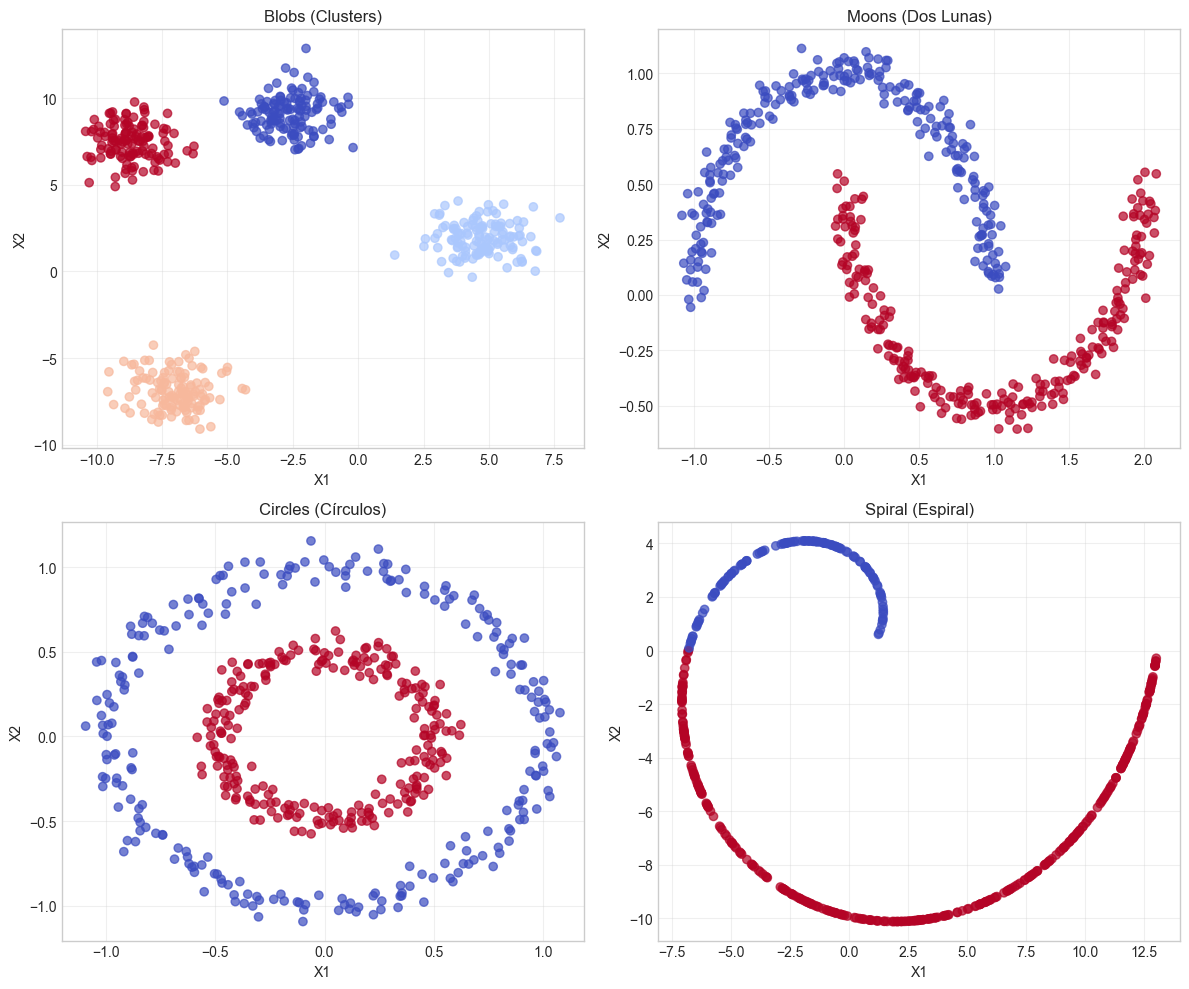

In [5]:
# Generar diferentes formas de datos en 2D

np.random.seed(42)

# 1. Blobs (clusters)
X_blobs, y_blobs = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42)

# 2. Moons (dos lunas)
X_moons, y_moons = make_moons(n_samples=500, noise=0.05, random_state=42)

# 3. Circles (círculos concéntricos)
X_circles, y_circles = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)

# 4. Espiral (personalizada)
n_points = 500
theta = np.sqrt(np.random.rand(n_points)) * 2 * np.pi
r = 2 * theta + 0.5
X_spiral = np.column_stack([r * np.cos(theta), r * np.sin(theta)])
y_spiral = (theta > np.pi).astype(int)

# Visualizar
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

datasets = [
    (X_blobs, y_blobs, 'Blobs (Clusters)', 'blue'),
    (X_moons, y_moons, 'Moons (Dos Lunas)', 'red'),
    (X_circles, y_circles, 'Circles (Círculos)', 'green'),
    (X_spiral, y_spiral, 'Spiral (Espiral)', 'purple')
]

for ax, (X, y, title, color) in zip(axes.flat, datasets):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.2 Datos en 3D - Visualización

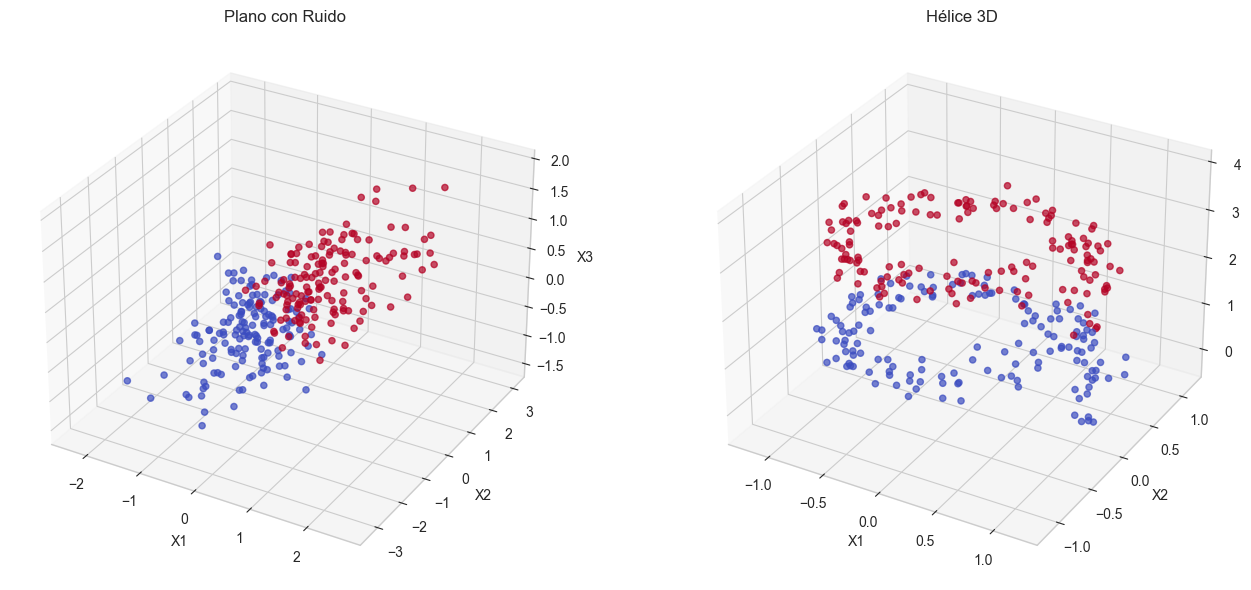

In [6]:
# Generar datos en 3D

np.random.seed(42)
n_samples = 300

# Datos en forma de plano con ruido
X_plane = np.random.randn(n_samples, 3)
X_plane[:, 2] = 0.5 * X_plane[:, 0] + 0.3 * X_plane[:, 1] + 0.2 * np.random.randn(n_samples)
y_plane = (X_plane[:, 2] > 0).astype(int)

# Datos en forma de espiral 3D
t = np.linspace(0, 4*np.pi, n_samples)
X_helix = np.column_stack([
    np.cos(t) + 0.1 * np.random.randn(n_samples),
    np.sin(t) + 0.1 * np.random.randn(n_samples),
    0.3 * t + 0.2 * np.random.randn(n_samples)
])
y_helix = (t > 2*np.pi).astype(int)

# Visualizar en 3D
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_plane[:, 0], X_plane[:, 1], X_plane[:, 2], c=y_plane, cmap='coolwarm', alpha=0.7)
ax1.set_title('Plano con Ruido')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('X3')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_helix[:, 0], X_helix[:, 1], X_helix[:, 2], c=y_helix, cmap='coolwarm', alpha=0.7)
ax2.set_title('Hélice 3D')
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.set_zlabel('X3')

plt.tight_layout()
plt.show()

---
## 2. PCA - Principal Component Analysis

### 2.1 PCA en Datos 2D

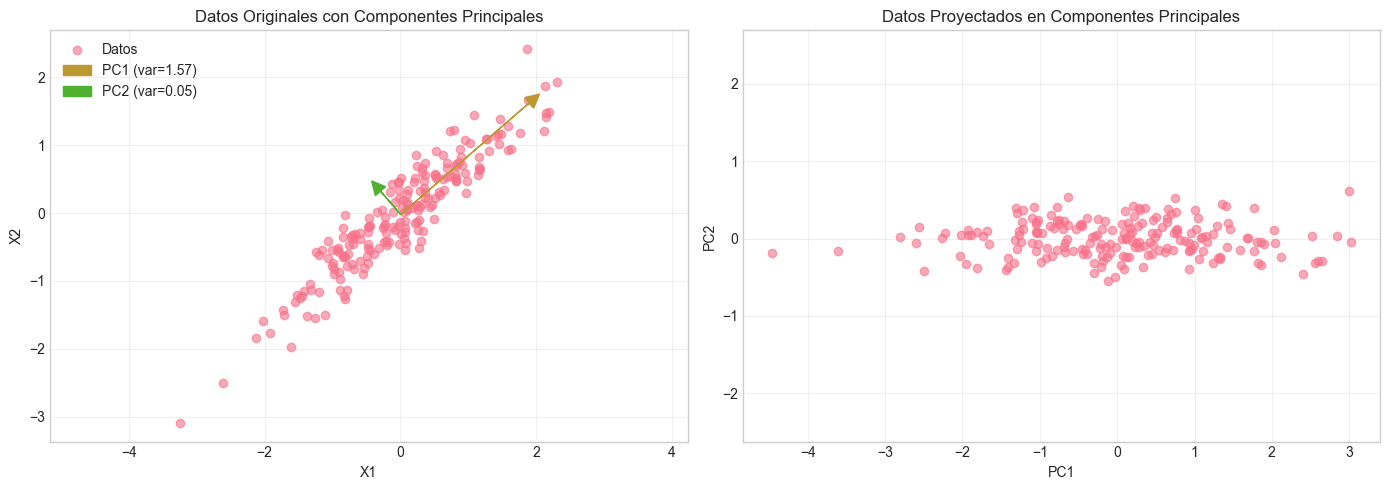

Varianza explicada por PC1: 0.9681
Varianza explicada por PC2: 0.0319
Varianza total explicada: 1.0000


In [7]:
# PCA en datos 2D - Visualización de componentes principales

np.random.seed(42)

# Generar datos con correlación
n_samples = 200
X_pca_2d = np.random.randn(n_samples, 2)
X_pca_2d[:, 1] = 0.8 * X_pca_2d[:, 0] + 0.3 * np.random.randn(n_samples)

# Aplicar PCA
pca_2d = PCA(n_components=2)
X_pca_transformed = pca_2d.fit_transform(X_pca_2d)

# Obtener componentes principales
components = pca_2d.components_
mean = pca_2d.mean_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Datos originales
ax = axes[0]
ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.6, label='Datos')

# Dibujar componentes principales
for i, (comp, var) in enumerate(zip(components, pca_2d.explained_variance_)):
    # Escalar por la varianza para visualización
    length = 2 * np.sqrt(var)
    ax.arrow(mean[0], mean[1], comp[0] * length, comp[1] * length,
             head_width=0.2, head_length=0.2, 
             fc=f'C{i+1}', ec=f'C{i+1}', label=f'PC{i+1} (var={var:.2f})')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('Datos Originales con Componentes Principales')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axis('equal')

# Datos transformados
ax = axes[1]
ax.scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1], alpha=0.6)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Datos Proyectados en Componentes Principales')
ax.grid(True, alpha=0.3)
ax.axis('equal')

plt.tight_layout()
plt.show()

print(f"Varianza explicada por PC1: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"Varianza explicada por PC2: {pca_2d.explained_variance_ratio_[1]:.4f}")
print(f"Varianza total explicada: {pca_2d.explained_variance_ratio_.sum():.4f}")

### 2.2 PCA en Datos 3D

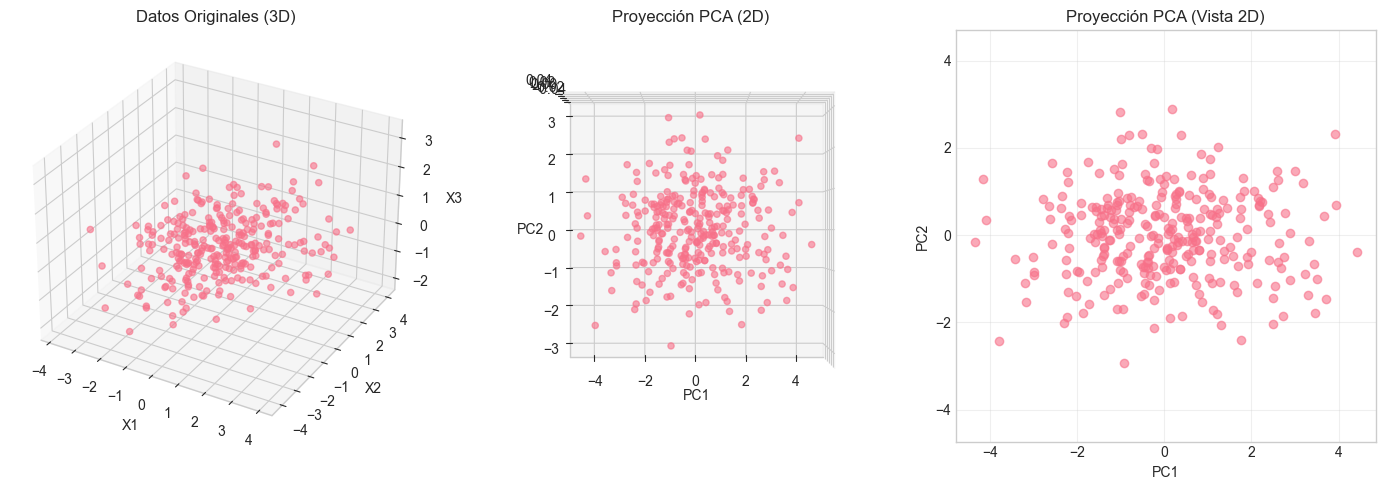

Varianza explicada por PC1: 0.6277
Varianza explicada por PC2: 0.2391
Varianza total explicada: 0.8668


In [8]:
# PCA en datos 3D - Reducción a 2D

np.random.seed(42)
n_samples = 300

# Generar datos en 3D (elipsoide)
X_pca_3d = np.random.randn(n_samples, 3)
# Aplicar transformación para crear correlación
transform = np.array([[1.5, 0.3, 0.1], [0.3, 1.2, 0.2], [0.1, 0.2, 0.8]])
X_pca_3d = X_pca_3d @ transform

# Aplicar PCA a 2D
pca_3d = PCA(n_components=2)
X_pca_3d_reduced = pca_3d.fit_transform(X_pca_3d)

fig = plt.figure(figsize=(14, 5))

# Datos originales en 3D
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], alpha=0.6)
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('X3')
ax1.set_title('Datos Originales (3D)')

# Proyección PCA
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(X_pca_3d_reduced[:, 0], X_pca_3d_reduced[:, 1], np.zeros(n_samples), alpha=0.6)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('')
ax2.set_title('Proyección PCA (2D)')
ax2.view_init(elev=90, azim=-90)

# Datos reducidos en 2D
ax3 = fig.add_subplot(133)
ax3.scatter(X_pca_3d_reduced[:, 0], X_pca_3d_reduced[:, 1], alpha=0.6)
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_title('Proyección PCA (Vista 2D)')
ax3.grid(True, alpha=0.3)
ax3.axis('equal')

plt.tight_layout()
plt.show()

print(f"Varianza explicada por PC1: {pca_3d.explained_variance_ratio_[0]:.4f}")
print(f"Varianza explicada por PC2: {pca_3d.explained_variance_ratio_[1]:.4f}")
print(f"Varianza total explicada: {pca_3d.explained_variance_ratio_.sum():.4f}")

### 2.3 PCA en MNIST (Digits Dataset)

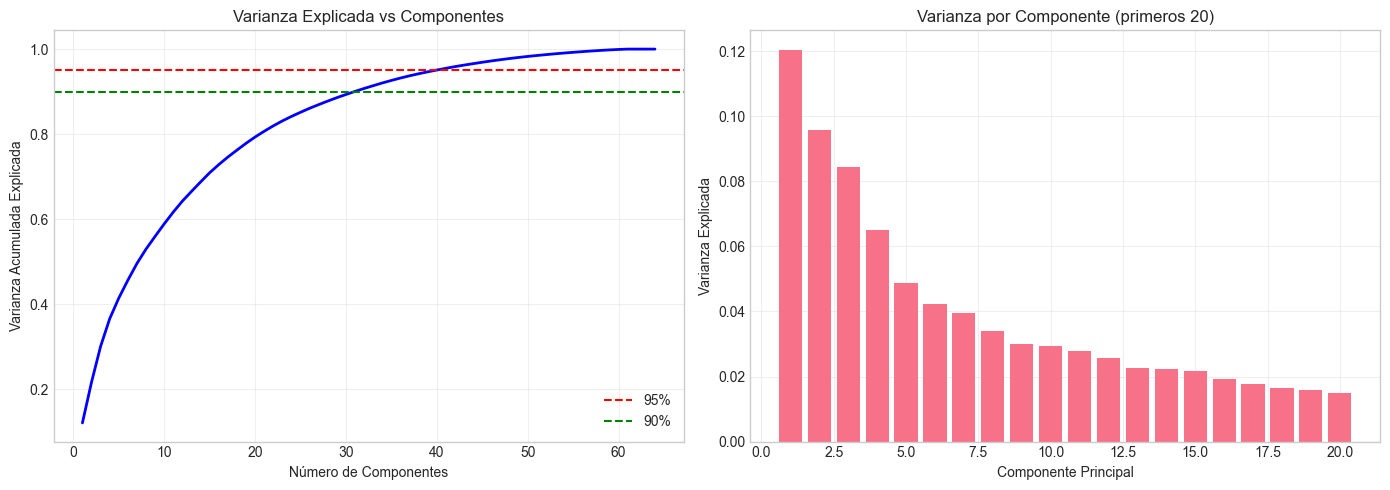

Dimensiones originales: 64
Componentes para 95% de varianza: 40
Componentes para 90% de varianza: 31


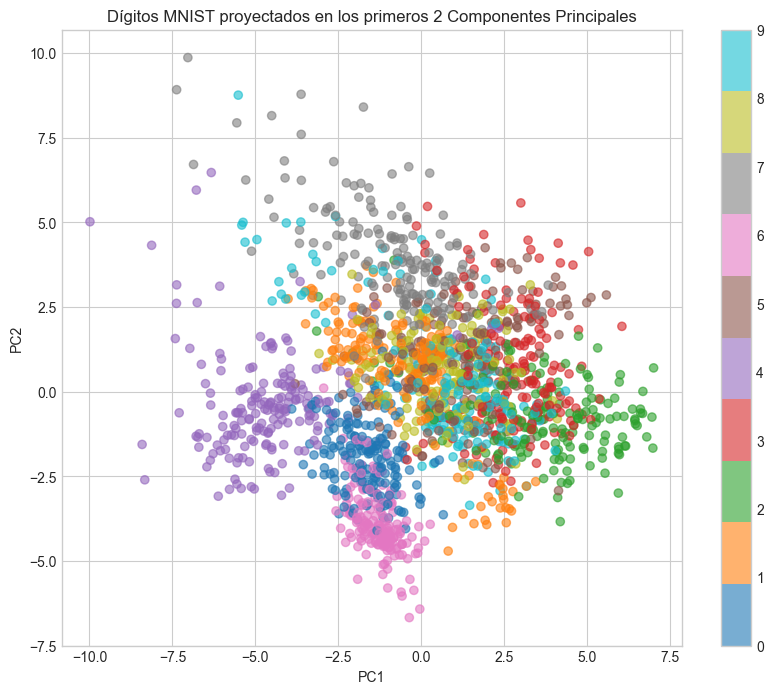

In [9]:
# PCA en el dataset de dígitos (MNIST reducido)

digits = load_digits()
X_digits, y_digits = digits.data, digits.target

# Escalar datos
scaler = StandardScaler()
X_digits_scaled = scaler.fit_transform(X_digits)

# Aplicar PCA
pca_digits = PCA()
X_digits_pca = pca_digits.fit_transform(X_digits_scaled)

# Visualizar varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza acumulada
ax = axes[0]
cumulative_variance = np.cumsum(pca_digits.explained_variance_ratio_)
ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'b-', linewidth=2)
ax.axhline(y=0.95, color='r', linestyle='--', label='95%')
ax.axhline(y=0.90, color='g', linestyle='--', label='90%')
ax.set_xlabel('Número de Componentes')
ax.set_ylabel('Varianza Acumulada Explicada')
ax.set_title('Varianza Explicada vs Componentes')
ax.legend()
ax.grid(True, alpha=0.3)

# Varianza por componente
ax = axes[1]
ax.bar(range(1, 21), pca_digits.explained_variance_ratio_[:20])
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Varianza Explicada')
ax.set_title('Varianza por Componente (primeros 20)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Dimensiones originales: {X_digits.shape[1]}")
print(f"Componentes para 95% de varianza: {np.argmax(cumulative_variance >= 0.95) + 1}")
print(f"Componentes para 90% de varianza: {np.argmax(cumulative_variance >= 0.90) + 1}")

# Visualizar los primeros 2 componentes
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_digits_pca[:, 0], X_digits_pca[:, 1], c=y_digits, cmap='tab10', alpha=0.6)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Dígitos MNIST proyectados en los primeros 2 Componentes Principales')
plt.colorbar(scatter)
plt.show()

---
## 3. t-SNE - t-Distributed Stochastic Neighbor Embedding

### 3.1 Comparación PCA vs t-SNE en datos sintéticos

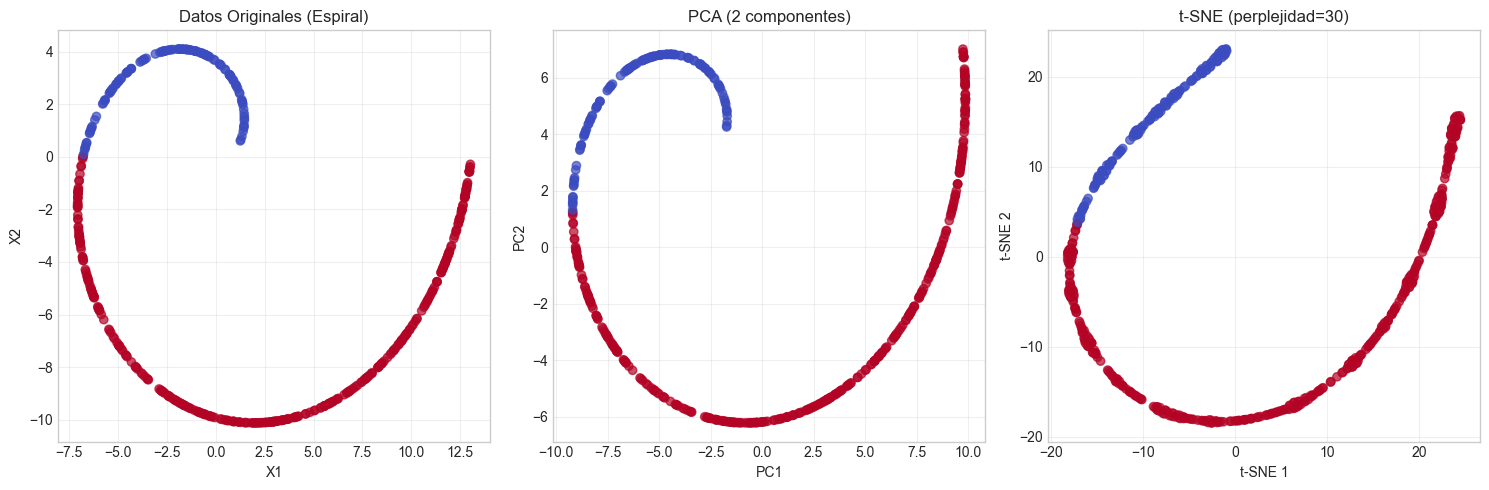

In [10]:
# Comparación PCA vs t-SNE en datos con estructura no lineal

# Usar datos de espiral (estructura no lineal)
X_tsne = X_spiral.copy()
y_tsne = y_spiral.copy()

# Aplicar PCA
pca_tsne = PCA(n_components=2)
X_pca_tsne = pca_tsne.fit_transform(X_tsne)

# Aplicar t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_result = tsne.fit_transform(X_tsne)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Datos originales
ax = axes[0]
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_tsne, cmap='coolwarm', alpha=0.7)
ax.set_title('Datos Originales (Espiral)')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.grid(True, alpha=0.3)

# PCA
ax = axes[1]
ax.scatter(X_pca_tsne[:, 0], X_pca_tsne[:, 1], c=y_tsne, cmap='coolwarm', alpha=0.7)
ax.set_title('PCA (2 componentes)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(True, alpha=0.3)

# t-SNE
ax = axes[2]
ax.scatter(X_tsne_result[:, 0], X_tsne_result[:, 1], c=y_tsne, cmap='coolwarm', alpha=0.7)
ax.set_title('t-SNE (perplejidad=30)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 Efecto de la Perplejidad en t-SNE

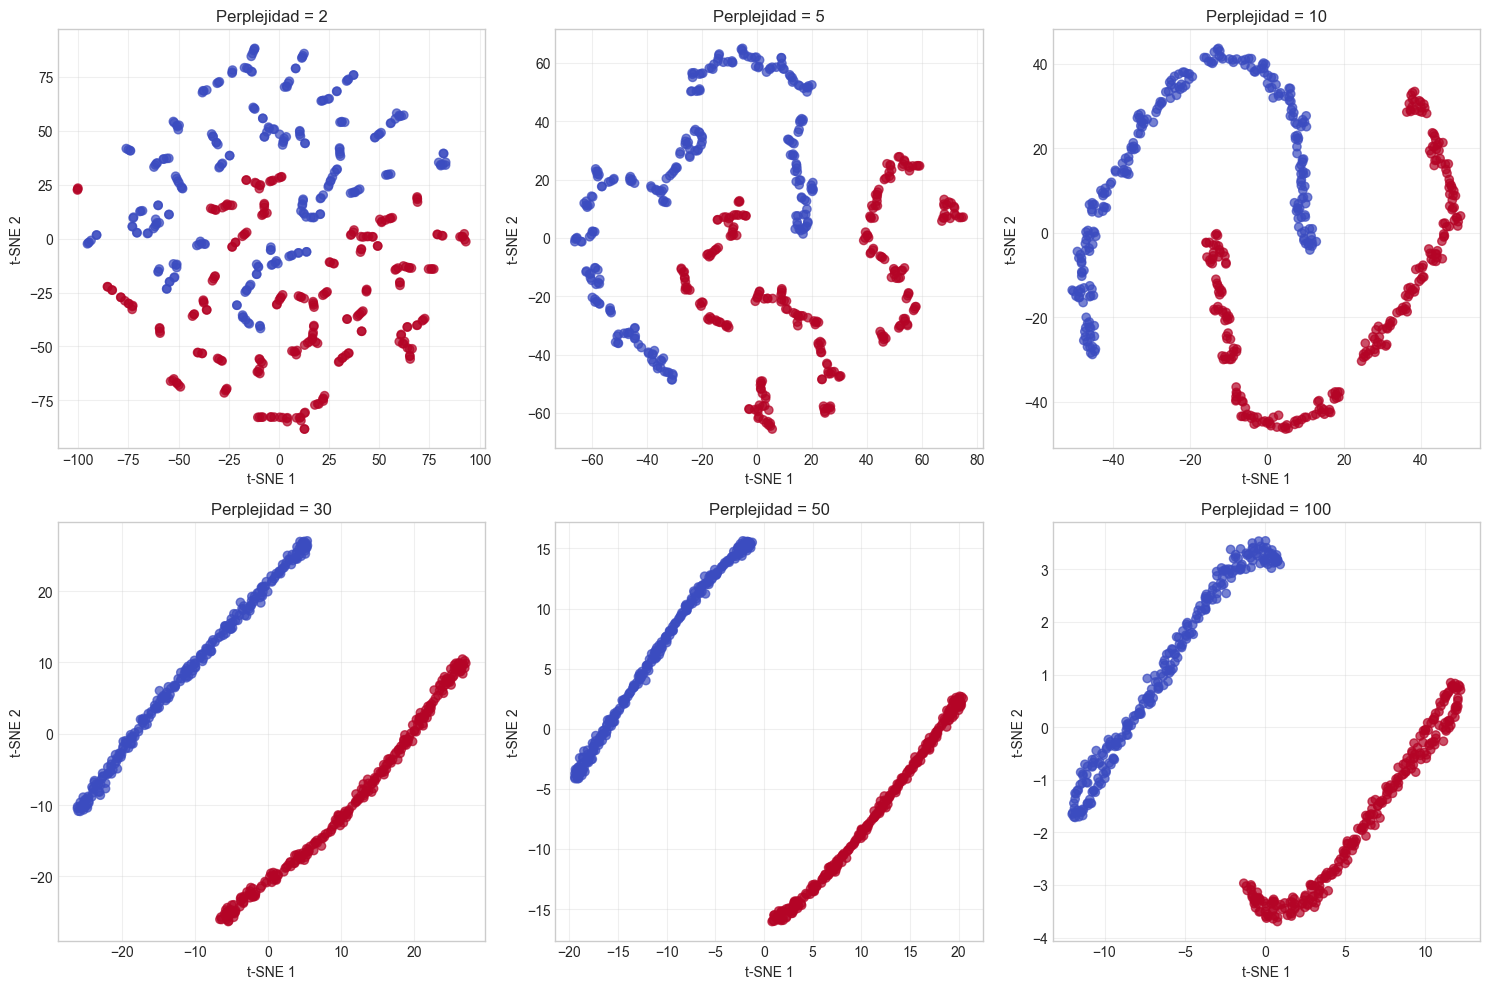

In [11]:
# Efecto de diferentes valores de perplejidad en t-SNE

# Usar datos de dos lunas
X_tsne_perp = X_moons.copy()
y_tsne_perp = y_moons.copy()

perplexities = [2, 5, 10, 30, 50, 100]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, perp in zip(axes.flat, perplexities):
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
    X_tsne_result = tsne.fit_transform(X_tsne_perp)
    ax.scatter(X_tsne_result[:, 0], X_tsne_result[:, 1], c=y_tsne_perp, cmap='coolwarm', alpha=0.7)
    ax.set_title(f'Perplejidad = {perp}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 t-SNE en MNIST

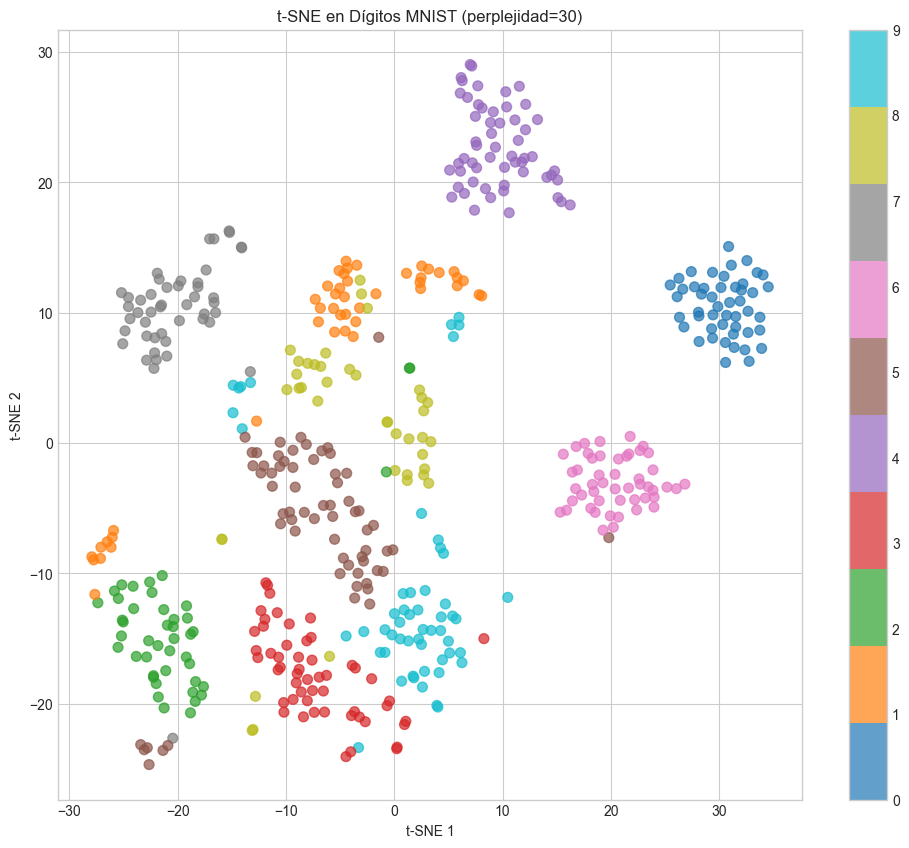

In [12]:
# t-SNE en dígitos MNIST

# Usar una muestra más pequeña para t-SNE (es costoso)
np.random.seed(42)
n_samples_tsne = 500
indices = np.random.choice(len(X_digits_scaled), n_samples_tsne, replace=False)
X_sample = X_digits_scaled[indices]
y_sample = y_digits[indices]

# PCA primero (opcional, para acelerar t-SNE)
pca_tsne_digits = PCA(n_components=50)
X_sample_pca = pca_tsne_digits.fit_transform(X_sample)

# t-SNE
tsne_digits = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_digits = tsne_digits.fit_transform(X_sample_pca)

# Visualizar
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(X_tsne_digits[:, 0], X_tsne_digits[:, 1], 
                     c=y_sample, cmap='tab10', alpha=0.7, s=50)
ax.set_title('t-SNE en Dígitos MNIST (perplejidad=30)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.colorbar(scatter)
plt.show()

---
## 4. UMAP - Uniform Manifold Approximation and Projection

### 4.1 Comparación PCA, t-SNE, UMAP

h:\Anaconda\envs\deepf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


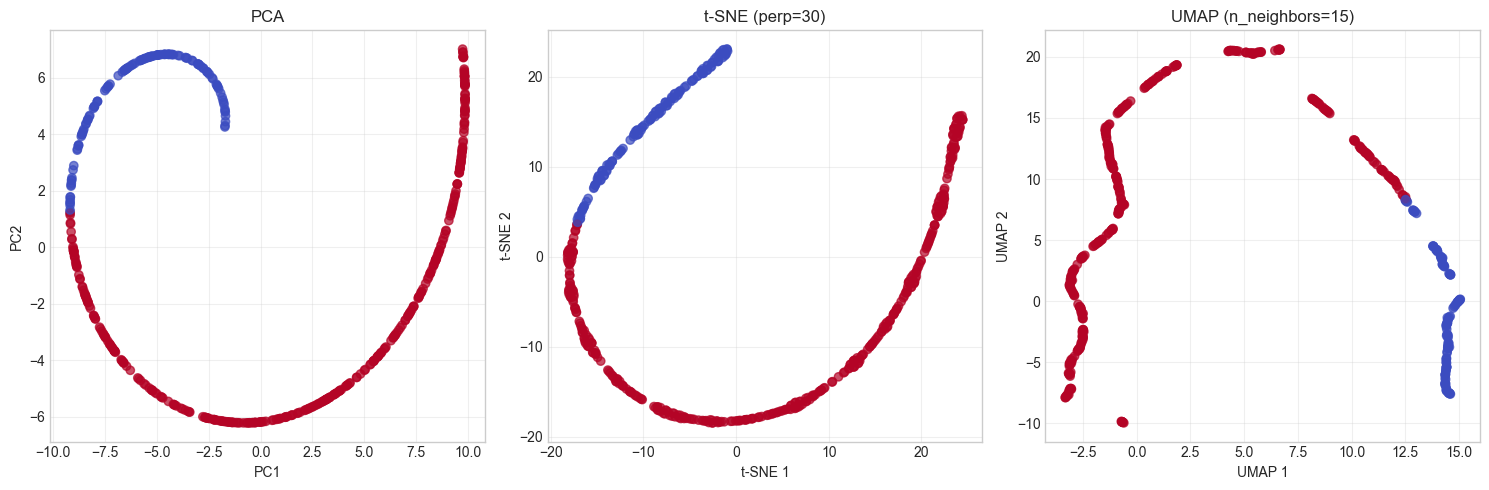

In [14]:
# Comparación de métodos en datos de espiral

if UMAP_AVAILABLE:
    X_umap = X_spiral.copy()
    y_umap = y_spiral.copy()
    
    # PCA
    pca_umap = PCA(n_components=2)
    X_pca_umap = pca_umap.fit_transform(X_umap)
    
    # t-SNE
    tsne_umap = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne_umap = tsne_umap.fit_transform(X_umap)
    
    # UMAP
    umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    X_umap_result = umap_model.fit_transform(X_umap)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].scatter(X_pca_umap[:, 0], X_pca_umap[:, 1], c=y_umap, cmap='coolwarm', alpha=0.7)
    axes[0].set_title('PCA')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].scatter(X_tsne_umap[:, 0], X_tsne_umap[:, 1], c=y_umap, cmap='coolwarm', alpha=0.7)
    axes[1].set_title('t-SNE (perp=30)')
    axes[1].set_xlabel('t-SNE 1')
    axes[1].set_ylabel('t-SNE 2')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].scatter(X_umap_result[:, 0], X_umap_result[:, 1], c=y_umap, cmap='coolwarm', alpha=0.7)
    axes[2].set_title('UMAP (n_neighbors=15)')
    axes[2].set_xlabel('UMAP 1')
    axes[2].set_ylabel('UMAP 2')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("UMAP no disponible. Instalar con: pip install umap-learn")

### 4.2 Efecto de n_neighbors en UMAP

h:\Anaconda\envs\deepf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
h:\Anaconda\envs\deepf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
h:\Anaconda\envs\deepf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
h:\Anaconda\envs\deepf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
h:\Anaconda\envs\deepf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
h:\Anaconda\envs\deepf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn

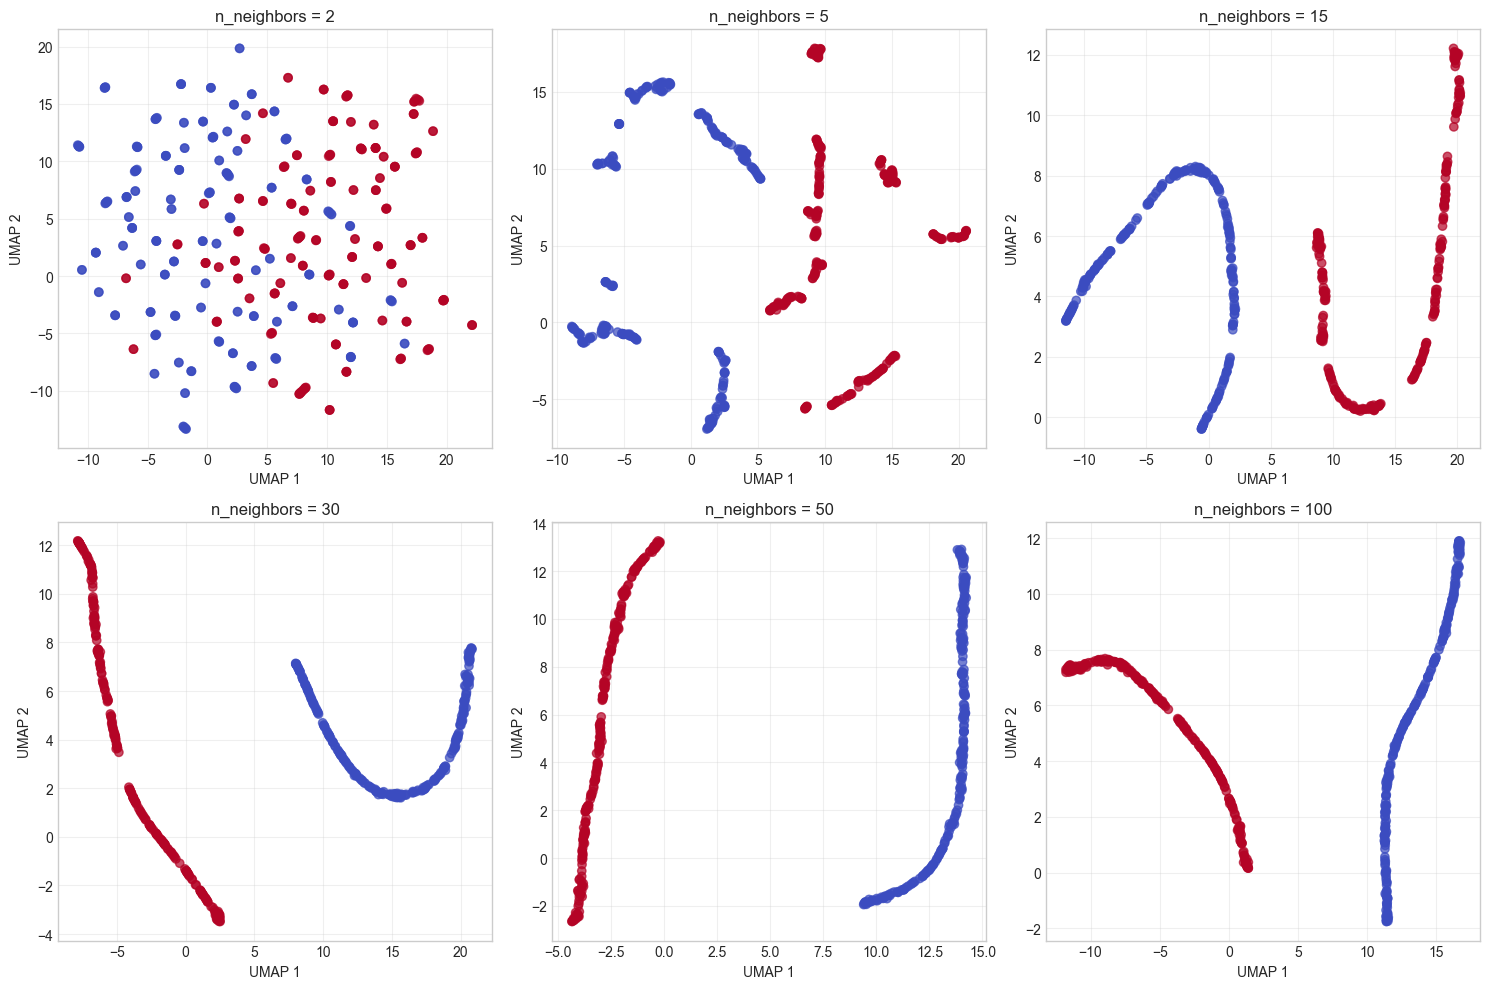

In [15]:
# Efecto de diferentes valores de n_neighbors en UMAP

if UMAP_AVAILABLE:
    X_umap_neighbors = X_moons.copy()
    y_umap_neighbors = y_moons.copy()
    
    n_neighbors_values = [2, 5, 15, 30, 50, 100]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for ax, n_neighbors in zip(axes.flat, n_neighbors_values):
        umap_model = umap.UMAP(n_components=2, random_state=42, 
                              n_neighbors=n_neighbors, min_dist=0.1)
        X_umap_result = umap_model.fit_transform(X_umap_neighbors)
        ax.scatter(X_umap_result[:, 0], X_umap_result[:, 1], 
                  c=y_umap_neighbors, cmap='coolwarm', alpha=0.7)
        ax.set_title(f'n_neighbors = {n_neighbors}')
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("UMAP no disponible.")

---
## 5. Word Embeddings

### 5.1 Word2Vec con Texto Simple

Palabras similares a 'gato':
  grande: 0.1847
  negro: 0.1711
  amigos: 0.1662
  casa: 0.1366
  el: 0.1319
  corre: 0.1184
  duerme: 0.1153
  en: 0.1125
  marron: 0.1124
  está: 0.0963

Palabras similares a 'casa':
  jardín: 0.1657
  corre: 0.1538
  negro: 0.1382
  gato: 0.1366
  bonita: 0.1276
  y: 0.1248
  grande: 0.1071
  la: 0.1024
  flores: 0.0402
  un: 0.0304

Vector de 'gato': [ 0.00855331  0.00014155 -0.01916767 -0.01931752 -0.01229995]...
Vector de 'perro': [ 0.01563596 -0.01902602 -0.00041408  0.00694257 -0.00187772]...


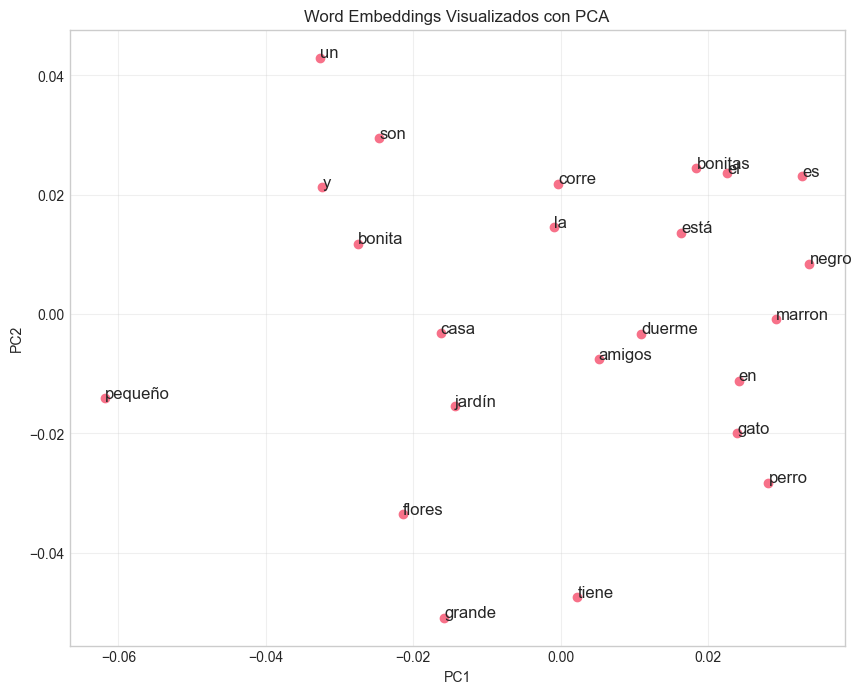

In [16]:
# Word2Vec con texto simple

if GENSIM_AVAILABLE:
    # Corpus de ejemplo
    sentences = [
        ['el', 'gato', 'está', 'en', 'la', 'casa'],
        ['el', 'perro', 'está', 'en', 'el', 'jardín'],
        ['el', 'gato', 'es', 'negro', 'y', 'pequeño'],
        ['el', 'perro', 'es', 'grande', 'y', 'marron'],
        ['la', 'casa', 'tiene', 'un', 'jardín', 'grande'],
        ['el', 'gato', 'y', 'el', 'perro', 'son', 'amigos'],
        ['la', 'casa', 'es', 'grande', 'y', 'bonita'],
        ['el', 'jardín', 'tiene', 'flores', 'bonitas'],
        ['el', 'perro', 'corre', 'en', 'el', 'jardín'],
        ['el', 'gato', 'duerme', 'en', 'la', 'casa']
    ]
    
    # Entrenar Word2Vec
    model_w2v = Word2Vec(sentences, vector_size=50, window=3, min_count=1, workers=4)
    
    # Palabras similares
    print("Palabras similares a 'gato':")
    try:
        for word, score in model_w2v.wv.most_similar('gato'):
            print(f"  {word}: {score:.4f}")
    except KeyError:
        print("  Palabra no encontrada")
    
    print("\nPalabras similares a 'casa':")
    try:
        for word, score in model_w2v.wv.most_similar('casa'):
            print(f"  {word}: {score:.4f}")
    except KeyError:
        print("  Palabra no encontrada")
    
    # Vector de una palabra
    print(f"\nVector de 'gato': {model_w2v.wv['gato'][:5]}...")
    print(f"Vector de 'perro': {model_w2v.wv['perro'][:5]}...")
    
    # Visualización de embeddings con PCA
    from sklearn.decomposition import PCA
    
    words = list(model_w2v.wv.index_to_key)
    vectors = np.array([model_w2v.wv[word] for word in words])
    
    pca_w2v = PCA(n_components=2)
    vectors_2d = pca_w2v.fit_transform(vectors)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1])
    for i, word in enumerate(words):
        ax.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=12)
    ax.set_title('Word Embeddings Visualizados con PCA')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)
    plt.show()
else:
    print("Gensim no disponible. Instalar con: pip install gensim")

### 5.2 Analogías Semánticas

In [17]:
# Analogías semánticas con Word2Vec

if GENSIM_AVAILABLE:
    # Crear un corpus más grande para analogías
    sentences_large = [
        ['rey', 'hombre', 'reina', 'mujer'],
        ['rey', 'es', 'el', 'hombre', 'que', 'gobierna'],
        ['reina', 'es', 'la', 'mujer', 'que', 'gobierna'],
        ['hombre', 'es', 'un', 'ser', 'humano', 'masculino'],
        ['mujer', 'es', 'un', 'ser', 'humano', 'femenino'],
        ['paris', 'es', 'la', 'capital', 'de', 'francia'],
        ['madrid', 'es', 'la', 'capital', 'de', 'españa'],
        ['roma', 'es', 'la', 'capital', 'de', 'italia'],
        ['francia', 'es', 'un', 'país', 'europeo'],
        ['españa', 'es', 'un', 'país', 'europeo'],
        ['italia', 'es', 'un', 'país', 'europeo'],
        ['el', 'rey', 'es', 'el', 'padre', 'de', 'la', 'reina'],
        ['la', 'reina', 'es', 'la', 'madre', 'del', 'rey'],
        ['el', 'hombre', 'camina', 'hacia', 'la', 'mujer'],
        ['la', 'mujer', 'camina', 'hacia', 'el', 'hombre'],
    ]
    
    # Entrenar modelo
    model_analogies = Word2Vec(sentences_large, vector_size=50, window=3, min_count=1, workers=4)
    
    print("Analogías:")
    print("\nRey - Hombre + Mujer = ?")
    try:
        result = model_analogies.wv.most_similar(positive=['rey', 'mujer'], negative=['hombre'])
        for word, score in result:
            print(f"  {word}: {score:.4f}")
    except KeyError:
        print("  Palabras no encontradas")
    
    print("\nParís - Francia + España = ?")
    try:
        result = model_analogies.wv.most_similar(positive=['paris', 'españa'], negative=['francia'])
        for word, score in result:
            print(f"  {word}: {score:.4f}")
    except KeyError:
        print("  Palabras no encontradas")
else:
    print("Gensim no disponible.")

Analogías:

Rey - Hombre + Mujer = ?
  un: 0.1859
  madre: 0.1649
  reina: 0.1629
  país: 0.1265
  femenino: 0.1132
  españa: 0.1093
  paris: 0.0967
  roma: 0.0713
  francia: 0.0129
  el: -0.0047

París - Francia + España = ?
  rey: 0.4325
  padre: 0.1794
  reina: 0.1279
  roma: 0.1257
  un: 0.1148
  del: 0.0921
  masculino: 0.0862
  hombre: 0.0799
  país: 0.0788
  que: 0.0629
